In [1]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
data_dir = r"C:\Users\banav\Downloads\BloodCell\dataset2-master\dataset2-master\images\TRAIN"
#Define the class lables
class_labels = ['eosinophil','lymphocyte','monocyte','neutrophil']

In [3]:
filepaths = []
labels = []

for label in class_labels:
    class_dir = os.path.join(data_dir, label)
    for file in os.listdir(class_dir):
        if file.lower().endswith(('.jpeg', '.png', '.jpg')):
            filepaths.append(os.path.join(class_dir, file))
            labels.append(label)


In [4]:
bloodCell_df = pd.DataFrame({
    'filepaths':filepaths,
    'labels':labels
})

In [5]:
bloodCell_df = bloodCell_df.sample(frac = 1).reset_index(drop=True)

In [6]:
bloodCell_df.head()

,filepaths,labels
0,C:\Users\banav\Downloads\BloodCell\dataset2-ma...,eosinophil
1,C:\Users\banav\Downloads\BloodCell\dataset2-ma...,neutrophil
2,C:\Users\banav\Downloads\BloodCell\dataset2-ma...,lymphocyte
3,C:\Users\banav\Downloads\BloodCell\dataset2-ma...,eosinophil
4,C:\Users\banav\Downloads\BloodCell\dataset2-ma...,monocyte


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = r"C:\Users\banav\Downloads\BloodCell\dataset2-master\dataset2-master\images\TRAIN"

train_datagen = ImageDataGenerator(rescale=1./255)

train = train_datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

print("Train created successfully")

Found 9957 images belonging to 4 classes.
Train created successfully


In [8]:
import matplotlib.pyplot as plt
import numpy as np

def show_knee_images(image_gen):
    class_dict = image_gen.class_indices
    classes = list(class_dict.keys())

    images, labels = next(image_gen)

    plt.figure(figsize=(20, 20))
    r = min(len(labels), 25)

    for i in range(r):
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[i])
        index = np.argmax(labels[i])
        plt.title(classes[index], color="green", fontsize=16)
        plt.axis('off')

    plt.show()


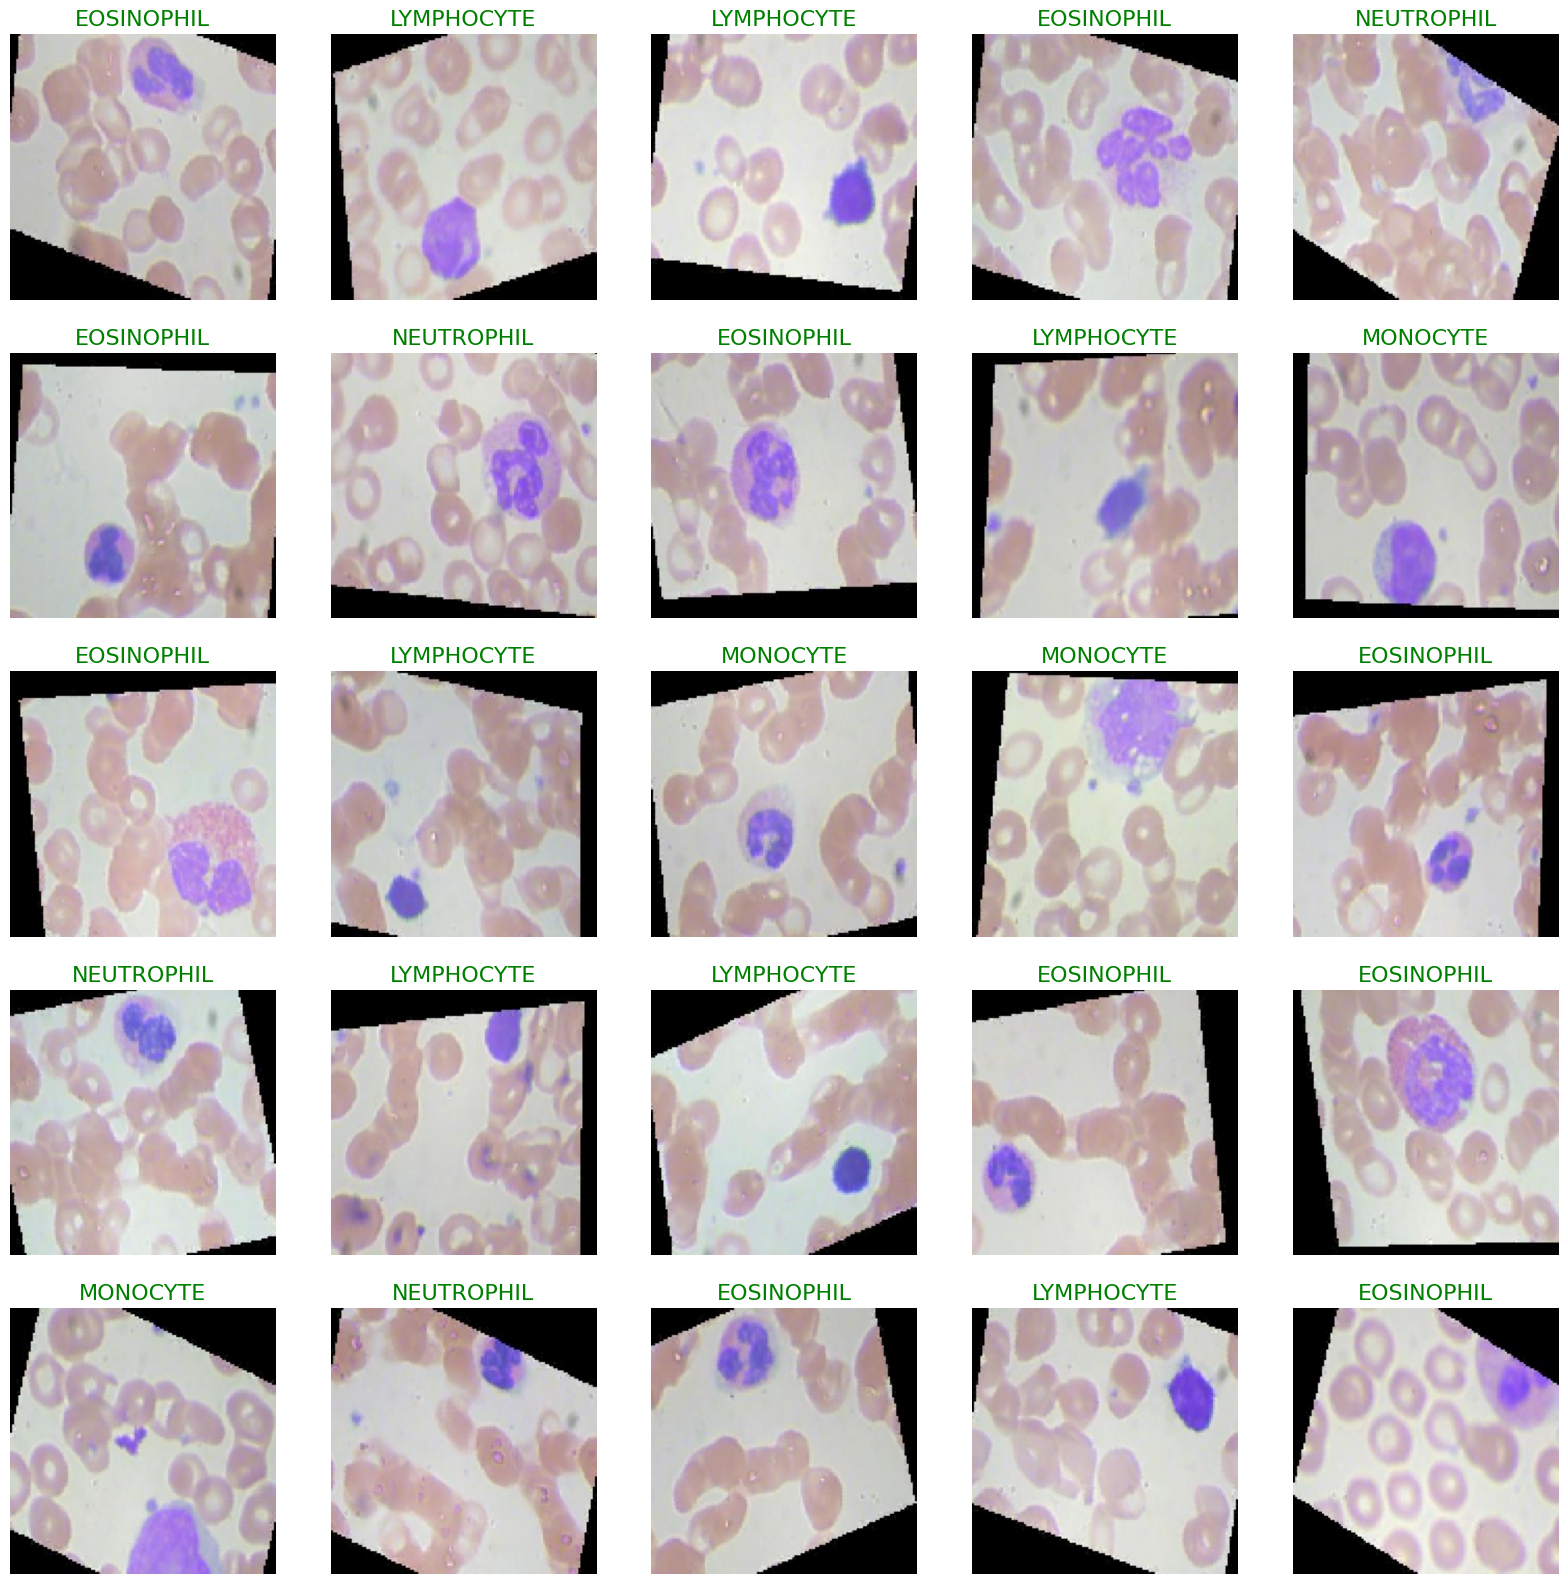

In [9]:
show_knee_images(train)

In [10]:
train_images,test_images = train_test_split(bloodCell_df, test_size=0.3,random_state=42)
train_set, val_set = train_test_split(bloodCell_df, test_size=0.2,random_state=42)
print(train_set.shape)
print(test_images.shape)
print(val_set.shape)
print(train_images.shape)

(7965, 2)
(2988, 2)
(1992, 2)
(6969, 2)


In [11]:
image_gen = ImageDataGenerator(preprocessing_function = tf.keras.applications.mobilenet_v2.preprocess_input)
train = image_gen.flow_from_dataframe(dataframe = train_set,x_col='filepaths',y_col='labels',
                                      target_size=(244,244),
                                      color_mode='rgb',
                                      class_mode='categorical',
                                      batch_size=8,
                                      shuffle=False
                                     )
test = image_gen.flow_from_dataframe(dataframe = test_images,x_col='filepaths',y_col='labels',
                                      target_size=(244,244),
                                      color_mode='rgb',
                                      class_mode='categorical',
                                      batch_size=8,
                                      shuffle=False
                                     )
val = image_gen.flow_from_dataframe(dataframe = val_set,x_col='filepaths',y_col='labels',
                                      target_size=(244,244),
                                      color_mode='rgb',
                                      class_mode='categorical',
                                      batch_size=8,
                                      shuffle=False
                                     )

Found 7965 validated image filenames belonging to 4 classes.
Found 2988 validated image filenames belonging to 4 classes.
Found 1992 validated image filenames belonging to 4 classes.


In [12]:
model = keras.models.Sequential([
    keras.layers.Conv2D(filters=128,kernel_size=(8,8),strides=(3,3),activation='relu',input_shape=(224,224,3)),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=256,kernel_size=(5,5),strides=(1,1),activation='relu',padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(3,3)),

    keras.layers.Conv2D(filters=256,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=256,kernel_size=(1,1),strides=(1,1),activation='relu',padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=256,kernel_size=(1,1),strides=(1,1),activation='relu',padding='same'),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=512,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(2,2)),

    keras.layers.Conv2D(filters=512,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same'),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=512,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same'),
    keras.layers.BatchNormalization(),

    keras.layers.MaxPool2D(pool_size=(2,2)),

    keras.layers.Conv2D(filters=512,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same'),
    keras.layers.BatchNormalization(),

    keras.layers.MaxPool2D(pool_size=(2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(4,activation='softmax')
])
model.compile(
    loss = 'categorical_crossentropy',
    optimizer = tf.optimizers.SGD(learning_rate=0.001),
    metrics = ['accuracy']
)
model.summary()

C:\Users\banav\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 73, 73, 128)         │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 73, 73, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 73, 73, 256)         │         819,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 73, 73, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 24, 24, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 24, 24, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 256)         │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 24, 24, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 24, 24, 256)         │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 24, 24, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 24, 24, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 24, 24, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 12, 12, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 12, 12, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 12, 12, 512)         │           2,0

 Total params: 15,611,524 (59.55 MB)

 Trainable params: 15,605,124 (59.53 MB)

 Non-trainable params: 6,400 (25.00 KB)

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

image_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train = image_gen.flow_from_dataframe(
    dataframe=train_set,
    x_col='filepaths',
    y_col='labels',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val = image_gen.flow_from_dataframe(
    dataframe=val_set,
    x_col='filepaths',
    y_col='labels',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test = image_gen.flow_from_dataframe(
    dataframe=test_images,
    x_col='filepaths',
    y_col='labels',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 7965 validated image filenames belonging to 4 classes.
Found 1992 validated image filenames belonging to 4 classes.
Found 2988 validated image filenames belonging to 4 classes.


In [18]:
num_classes = len(train.class_indices)

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step


In [19]:
history = model.fit(
    train,
    epochs=5,
    validation_data=val,
    verbose=1
)


C:\Users\banav\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 161s 619ms/step - accuracy: 0.5960 - loss: 0.9777 - val_accuracy: 0.7875 - val_loss: 0.5412
Epoch 2/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 148s 593ms/step - accuracy: 0.8125 - loss: 0.4976 - val_accuracy: 0.8292 - val_loss: 0.4203
Epoch 3/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 148s 594ms/step - accuracy: 0.8735 - loss: 0.3505 - val_accuracy: 0.8564 - val_loss: 0.3519
Epoch 4/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 148s 593ms/step - accuracy: 0.9016 - loss: 0.2797 - val_accuracy: 0.8795 - val_loss: 0.2972
Epoch 5/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 148s 593ms/step - accuracy: 0.9141 - loss: 0.2284 - val_accuracy: 0.8945 - val_loss: 0.2769


In [20]:
history1 = model.fit(
    train,
    epochs=1,
    validation_data=val,
    verbose=1
)

249/249 ━━━━━━━━━━━━━━━━━━━━ 150s 602ms/step - accuracy: 0.9522 - loss: 0.1579 - val_accuracy: 0.9071 - val_loss: 0.2606


In [23]:
pred = model.predict(test)
pred = np.argmax(pred, axis=1)

labels = (train.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred2 = [labels[k] for k in pred]

C:\Users\banav\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


94/94 ━━━━━━━━━━━━━━━━━━━━ 48s 495ms/step


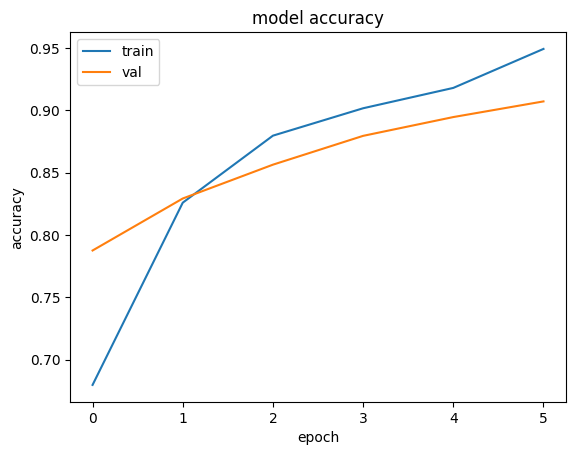

In [24]:
plt.plot(history.history['accuracy']+history1.history['accuracy'])
plt.plot(history.history['val_accuracy']+history1.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel("epoch")
plt.legend(['train','val'],loc='upper left')
plt.show()

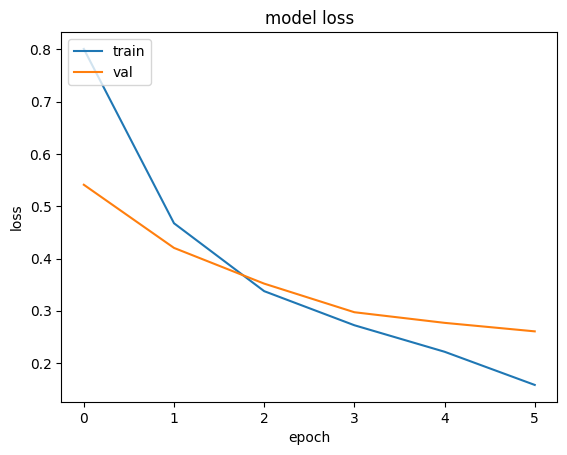

In [25]:
plt.plot(history.history['loss']+history1.history['loss'])
uplt.title('model loss')
plt.ylabel('loss')
plt.xlabel("epoch")
plt.legend(['train','val'],loc='upper left')
plt.show()

In [26]:
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.metrics import classification_report
y_test = test_images.labels
print(classification_report(y_test,pred2))
print("Accuracy of the model:","{:.1f}%".format(accuracy_score(y_test,pred2)*100))

              precision    recall  f1-score   support

  eosinophil       0.97      0.89      0.93       767
  lymphocyte       0.96      0.99      0.97       783
    monocyte       0.94      1.00      0.97       740
  neutrophil       0.93      0.92      0.93       698

    accuracy                           0.95      2988
   macro avg       0.95      0.95      0.95      2988
weighted avg       0.95      0.95      0.95      2988

Accuracy of the model: 94.9%


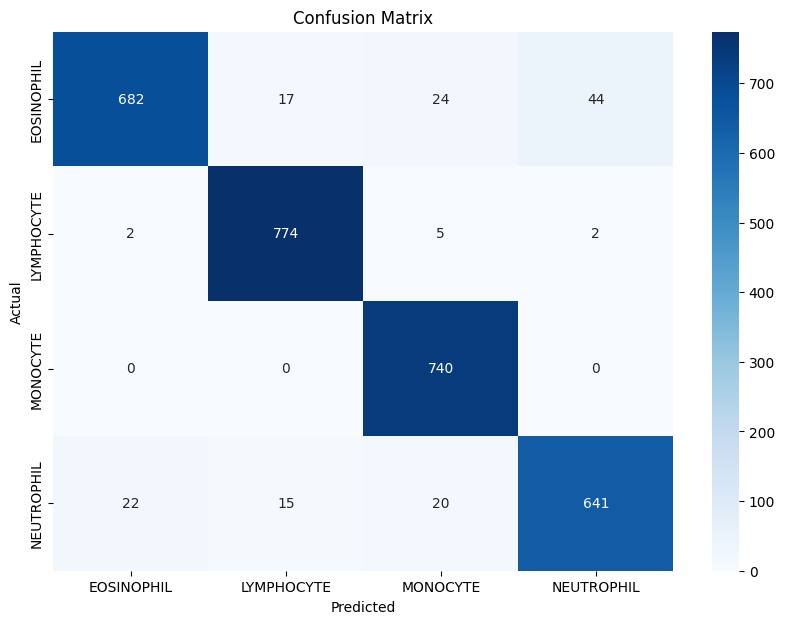

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
class_labels = ['EOSINOPHIL','LYMPHOCYTE','MONOCYTE','NEUTROPHIL']
cm = confusion_matrix(y_test,pred2)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues')

plt.xticks(ticks=[0.5,1.5,2.5,3.5], labels=class_labels)
plt.yticks(ticks=[0.5,1.5,2.5,3.5], labels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title("Confusion Matrix")
plt.show()

In [32]:
model.save("Blood Cell.h5")